# Gas technologies with DAC/E-DAC

Waste-heat DAC calculations consolidated with unit-checked inputs and a single set of assumptions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import src.matplotlib_style  # noqa: F401
from src.units import Units as U
import src.assumptions as A
from IPython.display import display
from pint import Quantity

plt.rcParams["figure.figsize"] = (7.5, 4.5)
plt.rcParams["figure.dpi"] = 120
pd.options.display.float_format = "{:,.2f}".format

GAS_CO2_INTENSITY_CCGT = 0.34 * U.t / U.MWh  # CCGT
GAS_CO2_INTENSITY_GT = 0.50 * U.t / U.MWh    # GT


## Technology assumptions

Efficiencies, waste-heat fractions, low-temperature usability, and DAC electricity draw for each gas technology.

In [2]:
edac_elec_per_t = 1.25 * U.MWh / U.t  # E-DAC electricity per tCO2

tech_params = pd.DataFrame(
    {
        "eta_elec": [0.55, 0.325, 0.55],
        "waste_frac": [0.45, 0.675, 0.45],
        "f_lowT": [1, 1, 1],
        "waste_temp_C": [171, 538, 171],
        "dac_elec_per_t": [
            A.LTDAC.ElectricityPerTonCO2.to(U.MWh / U.t),
            A.LTDAC.ElectricityPerTonCO2.to(U.MWh / U.t),
            edac_elec_per_t,
        ],
        "co2_intensity": [
            GAS_CO2_INTENSITY_CCGT,
            GAS_CO2_INTENSITY_GT,
            GAS_CO2_INTENSITY_CCGT,
        ],
    },
    index=[
        "CCGT (normal combined cycle)",
        "Gas Turbine (simple cycle)",
        "CCGT with E-DAC",
    ],
)


display(
    tech_params.assign(
        eta_elec_pct=lambda df: df["eta_elec"] * 100,
        waste_frac_pct=lambda df: df["waste_frac"] * 100,
        f_lowT_pct=lambda df: df["f_lowT"] * 100,
        dac_elec_mwh_per_t=lambda df: [x.to(U.MWh / U.t).magnitude for x in df["dac_elec_per_t"]],
    )["eta_elec_pct waste_frac_pct f_lowT_pct waste_temp_C dac_elec_mwh_per_t".split()]
    .rename(
        columns={
            "eta_elec_pct": "Electrical efficiency (%)",
            "waste_frac_pct": "Waste-heat fraction (%)",
            "f_lowT_pct": "Low-T usable fraction (%)",
            "waste_temp_C": "Waste-heat temp (C)",
            "dac_elec_mwh_per_t": "DAC electricity (MWh/tCO2)",
        }
    )
    .style.set_caption("Gas technology assumptions (fractions shown as %)")
)


,Electrical efficiency (%),Waste-heat fraction (%),Low-T usable fraction (%),Waste-heat temp (C),DAC electricity (MWh/tCO2)
CCGT (normal combined cycle),55.000000,45.000000,100,171,0.300389
Gas Turbine (simple cycle),32.500000,67.500000,100,538,0.300389
CCGT with E-DAC,55.000000,45.000000,100,171,1.250000


C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_27912\3234933581.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


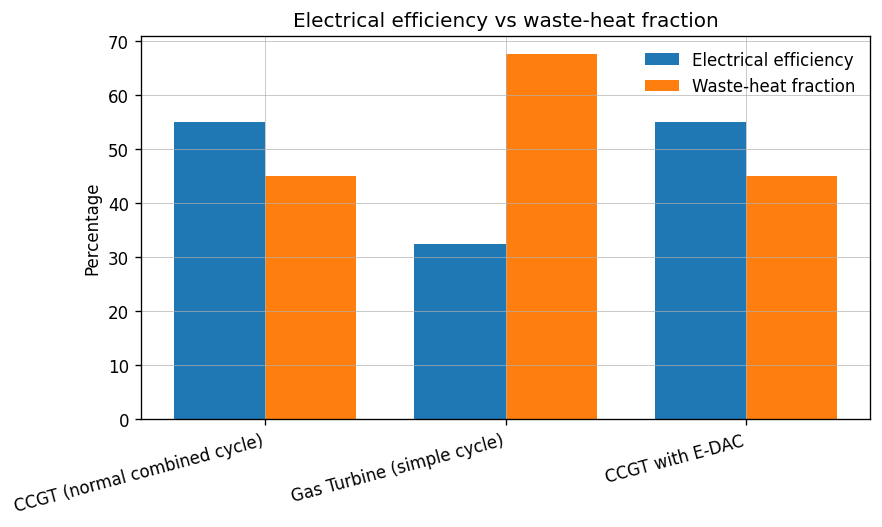

In [3]:
fig, ax = plt.subplots()
x = np.arange(len(tech_params))
width = 0.38

ax.bar(x - width / 2, tech_params["eta_elec"] * 100, width, label="Electrical efficiency")
ax.bar(x + width / 2, tech_params["waste_frac"] * 100, width, label="Waste-heat fraction")

ax.set_xticks(x)
ax.set_xticklabels(tech_params.index, rotation=15, ha="right")
ax.set_ylabel("Percentage")
ax.set_title("Electrical efficiency vs waste-heat fraction")
ax.legend()
plt.tight_layout()
plt.show()


C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_27912\3265993837.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


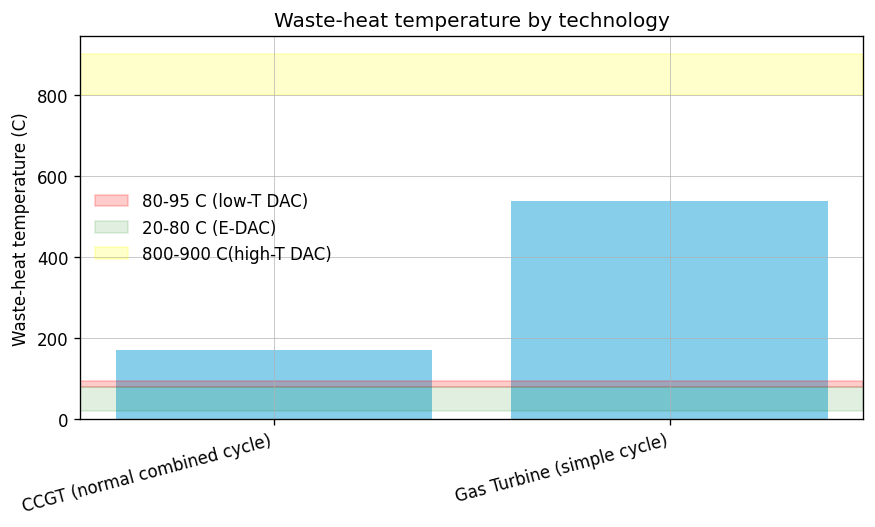

In [4]:
plot_params = tech_params.loc[
    ["CCGT (normal combined cycle)", "Gas Turbine (simple cycle)"]
]

fig, ax = plt.subplots()
x = np.arange(len(plot_params))
ax.bar(x, plot_params["waste_temp_C"], color="skyblue")

ax.axhspan(80, 95, color="red", alpha=0.20, label="80-95 C (low-T DAC)")
ax.axhspan(20, 80, color="green", alpha=0.12, label="20-80 C (E-DAC)")
ax.axhspan(800, 900, color="yellow", alpha=0.20, label="800-900 C(high-T DAC)")

ax.set_xticks(x)
ax.set_xticklabels(plot_params.index, rotation=15, ha="right")
ax.set_ylabel("Waste-heat temperature (C)")
ax.set_title("Waste-heat temperature by technology")
ax.legend()
plt.tight_layout()
plt.show()


## DAC and emissions parameters

Central DAC inputs stay aligned with `assumptions.py`.

In [5]:
H_DAC_MWH_PER_T = 1.1389 * U.MWh / U.t  # Heat per tonne of CO2 captured

GAS_CO2_INTENSITY_CCGT = 0.34 * U.t / U.MWh  # CCGT
GAS_CO2_INTENSITY_GT = 0.50 * U.t / U.MWh    # GT


DAC_COST_PER_T = 600 * U.GBP / U.t        # Capture cost used for quick cost scaling
HOURS_PER_YEAR = A.HoursPerYear


def annual_generation_from_capacity(capacity_gw: float, capacity_factor: float) -> Quantity:
    """Return annual generation in TWh from nameplate GW and capacity factor."""
    return (capacity_gw * U.GW * HOURS_PER_YEAR * capacity_factor).to(U.TWh)

example_gen_79gw = annual_generation_from_capacity(79, 0.85)
example_gen_79gw


<Quantity(588.6369, 'terawatt_hour')>

## Scenario setup and calculator

`compute_metrics` converts generation assumptions into emissions, DAC capture, electricity use, and costs with units enforced.

In [6]:
def compute_metrics(gen_twh: dict[str, float], edac_name: str | None = None) -> pd.DataFrame:
    rows = []
    for tech, gen_val in gen_twh.items():
        params = tech_params.loc[tech]
        eff = params["eta_elec"] * U.dimensionless
        waste_frac = params["waste_frac"] * U.dimensionless
        f_low = params["f_lowT"] * U.dimensionless
        dac_elec = params["dac_elec_per_t"]

        elec = gen_val * U.TWh
        fuel_input = elec / eff
        waste_heat = fuel_input * waste_frac
        usable_heat = waste_heat * f_low

        gross_emissions_t = (elec.to(U.MWh) * params["co2_intensity"]).to(U.t)


        if edac_name is not None and tech == edac_name:
            # uncapped: allow net-negative capture, limited only by available electricity
            usable_heat = 0 * U.MWh
            capture_t = (elec.to(U.MWh) / dac_elec).to(U.t)
        else:
            # take whatever the waste heat yields (can be net-positive or net-negative)
            capture_t = (usable_heat.to(U.MWh) / H_DAC_MWH_PER_T)

        dac_elec_MWh = (capture_t * dac_elec).to(U.MWh)
        net_emissions_t = gross_emissions_t - capture_t
        elec_surplus = elec.to(U.MWh) - dac_elec_MWh
        dac_cost = (capture_t * DAC_COST_PER_T).to(U.GBP)

        rows.append(
            {
                "Technology": tech,
                "Generation_TWh": elec.to(U.TWh).magnitude,
                "Fuel_input_TWh": fuel_input.to(U.TWh).magnitude,
                "Waste_heat_TWh": waste_heat.to(U.TWh).magnitude,
                "Usable_lowT_heat_TWh": usable_heat.to(U.TWh).magnitude,
                "Gas_emissions_MtCO2": gross_emissions_t.to(U.Mt).magnitude,
                "DAC_capture_MtCO2": capture_t.to(U.Mt).magnitude,
                "Net_emissions_MtCO2": net_emissions_t.to(U.Mt).magnitude,
                "DAC_electricity_TWh": dac_elec_MWh.to(U.TWh).magnitude,
                "Elec_surplus_after_DAC_TWh": elec_surplus.to(U.TWh).magnitude,
                "DAC_cost_billion_GBP": (dac_cost / (1e9 * U.GBP)).magnitude,
            }
        )

    return pd.DataFrame(rows).set_index("Technology").sort_index()


In [7]:
scenario_generation_TWh = {
    "CCGT (normal combined cycle)": 588,
    "Gas Turbine (simple cycle)": 588,
    "CCGT with E-DAC": 588,
}

results = compute_metrics(scenario_generation_TWh, edac_name="CCGT with E-DAC")

formatters = {
    "Generation_TWh": "{:.1f}",
    "Fuel_input_TWh": "{:.1f}",
    "Waste_heat_TWh": "{:.1f}",
    "Usable_lowT_heat_TWh": "{:.2f}",
    "Gas_emissions_MtCO2": "{:.2f}",
    "DAC_capture_MtCO2": "{:.2f}",
    "Net_emissions_MtCO2": "{:.2f}",
    "DAC_electricity_TWh": "{:.2f}",
    "Elec_surplus_after_DAC_TWh": "{:.2f}",
    "DAC_cost_billion_GBP": "{:.2f}",
}

results.style.format(formatters).set_caption(
    "Gas tech outputs: generation, emissions, DAC capture, and cost"
)





,Generation_TWh,Fuel_input_TWh,Waste_heat_TWh,Usable_lowT_heat_TWh,Gas_emissions_MtCO2,DAC_capture_MtCO2,Net_emissions_MtCO2,DAC_electricity_TWh,Elec_surplus_after_DAC_TWh,DAC_cost_billion_GBP
Technology,,,,,,,,,,
CCGT (normal combined cycle),588.0,1069.1,481.1,481.09,181.36,383.21,-201.85,126.89,461.11,253.45
CCGT with E-DAC,588.0,1069.1,481.1,0.00,181.36,426.74,-245.38,588.00,0.00,282.24
Gas Turbine (simple cycle),588.0,1809.2,1221.2,1221.23,266.71,972.76,-706.05,322.10,265.90,643.37


C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_27912\1251866924.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


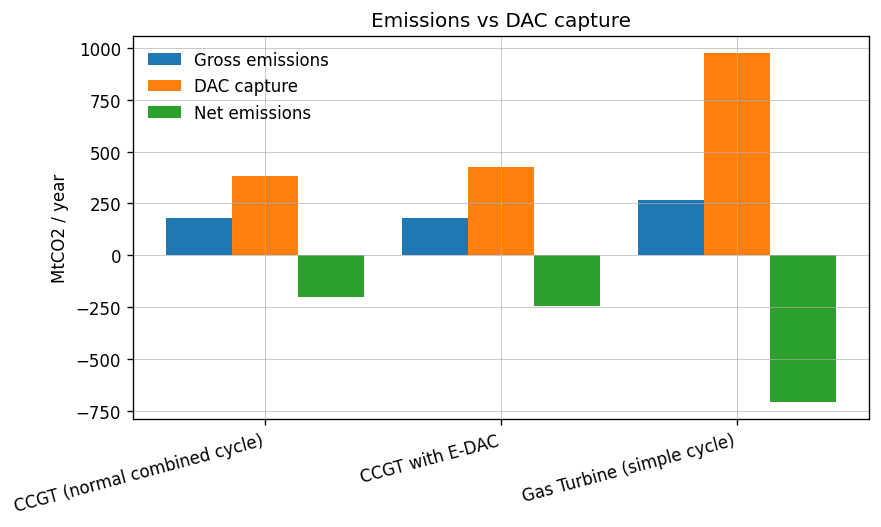

In [8]:
fig, ax = plt.subplots()
x = np.arange(len(results))
width = 0.28

ax.bar(x - width, results["Gas_emissions_MtCO2"], width, label="Gross emissions")
ax.bar(x, results["DAC_capture_MtCO2"], width, label="DAC capture")
ax.bar(x + width, results["Net_emissions_MtCO2"], width, label="Net emissions")

ax.set_xticks(x)
ax.set_xticklabels(results.index, rotation=15, ha="right")
ax.set_ylabel("MtCO2 / year")
ax.set_title("Emissions vs DAC capture")
ax.legend()
plt.tight_layout()
plt.show()


C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_27912\3960722695.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


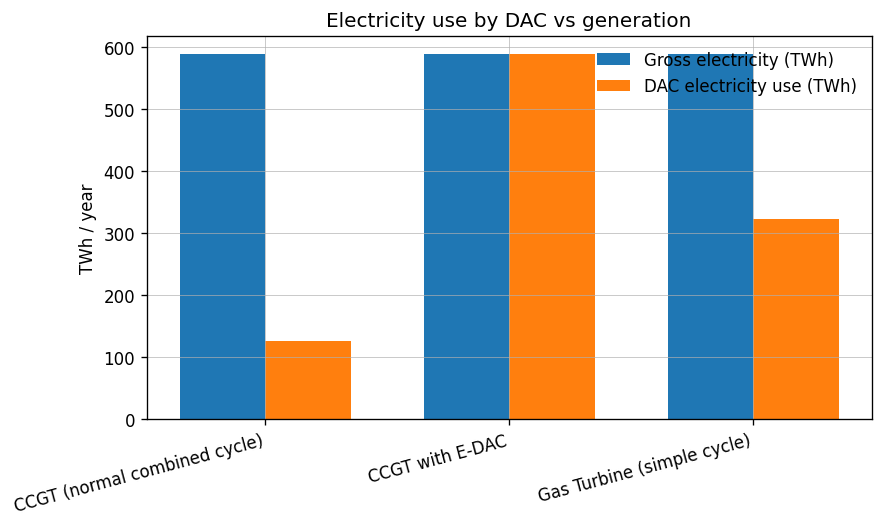

In [9]:
fig, ax = plt.subplots()
x = np.arange(len(results))
width = 0.35

ax.bar(x - width / 2, results["Generation_TWh"], width, label="Gross electricity (TWh)")
ax.bar(x + width / 2, results["DAC_electricity_TWh"], width, label="DAC electricity use (TWh)")

ax.set_xticks(x)
ax.set_xticklabels(results.index, rotation=15, ha="right")
ax.set_ylabel("TWh / year")
ax.set_title("Electricity use by DAC vs generation")
ax.legend()
plt.tight_layout()
plt.show()


C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_27912\3612722262.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


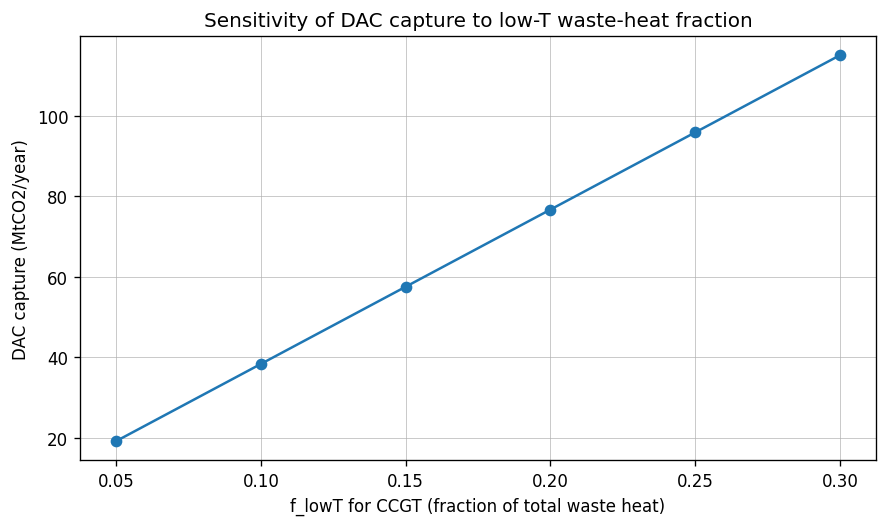

In [10]:
tech = "CCGT (normal combined cycle)"
f_values = np.linspace(0.05, 0.30, 6)
captures = []

params = tech_params.loc[tech]
elec = scenario_generation_TWh[tech] * U.TWh
emissions_t = (elec.to(U.MWh) * params["co2_intensity"]).to(U.t)
eff = params["eta_elec"] * U.dimensionless
waste_frac = params["waste_frac"] * U.dimensionless

for f in f_values:
    fuel_input = elec / eff
    waste_heat = fuel_input * waste_frac
    usable_heat = waste_heat * f
    capture_from_heat_t = (usable_heat.to(U.MWh) / H_DAC_MWH_PER_T).to(U.t)
    capture_t = min(emissions_t.magnitude, capture_from_heat_t.magnitude) * U.t
    captures.append(capture_t.to(U.Mt).magnitude)

fig, ax = plt.subplots()
ax.plot(f_values, captures, marker="o")
ax.set_xlabel("f_lowT for CCGT (fraction of total waste heat)")
ax.set_ylabel("DAC capture (MtCO2/year)")
ax.set_title("Sensitivity of DAC capture to low-T waste-heat fraction")
ax.grid(True)
plt.tight_layout()
plt.show()


### GT balance condition (DAC electricity = gross electricity)


**Symbols**
- $elec$: gross electricity generation (MWh)
- $\eta$: electrical efficiency (dimensionless)
- $f_{waste}$: waste‑heat fraction of fuel input (dimensionless)
- $f_{lowT}$: low‑temperature usable fraction of waste heat (dimensionless)
- $H_{DAC}$: thermal energy required per tCO2 (MWh/t)
- $e_{DAC}$: auxiliary electricity per tCO2 (MWh/t)
- $fuel$: fuel input energy (MWh)
- $waste$: waste heat energy (MWh)
- $usable$: usable low‑T heat (MWh)
- $cap$: CO2 captured by thermal DAC (tCO2)
- $dac\_elec$: DAC electricity use (MWh)

From the model:

$$
\mathrm{fuel} = \frac{\mathrm{elec}}{\eta}, \quad
\mathrm{waste} = \mathrm{fuel}\, f_{\mathrm{waste}}, \quad
\mathrm{usable} = \mathrm{waste}\, f_{\mathrm{lowT}}
$$

$$
\mathrm{cap} = \frac{\mathrm{usable}}{H_{\mathrm{DAC}}}, \quad
\mathrm{dac\_elec} = \mathrm{cap}\, e_{\mathrm{DAC}}
$$

So:

$$
\mathrm{dac\_elec} =
\mathrm{elec}\cdot \frac{f_{\mathrm{waste}}}{\eta}\cdot f_{\mathrm{lowT}}\cdot \frac{e_{\mathrm{DAC}}}{H_{\mathrm{DAC}}}
$$

Set $ \mathrm{dac\_elec} = \mathrm{elec} $ and solve:

$$
f_{\mathrm{lowT}} = \frac{\eta\, H_{\mathrm{DAC}}}{f_{\mathrm{waste}}\, e_{\mathrm{DAC}}}
$$

Numeric (GT):

$$
f_{\mathrm{lowT}} = \frac{0.33 \cdot 1.1389}{0.68 \cdot 0.365} \approx 1.514251
$$


In [11]:
from src.units import Units as U

# GT parameters
eta_elec = 0.33
waste_frac = 0.68
H_heat = 1.1389 * U.MWh / U.t
elec_per_t = 0.365 * U.MWh / U.t

# Pick generation
elec = 1.0 * U.TWh  # gross electricity

# Work backwards: set DAC electricity = gross electricity
# DAC electricity from thermal DAC:
#   dac_elec = (usable_heat / H_heat) * elec_per_t
#   usable_heat = fuel * waste_frac * f_lowT
#   fuel = elec / eta_elec
#
# So: dac_elec = (elec/eta_elec) * waste_frac * f_lowT / H_heat * elec_per_t
# Set dac_elec = elec, solve for f_lowT:

f_lowT_balance = (
    (elec * H_heat * eta_elec)
    / (elec_per_t * waste_frac * elec)
).to(U.dimensionless)

print(f"f_lowT_balance = {f_lowT_balance:.6f}")


f_lowT_balance = 1.514251 dimensionless


#### Grid efficiency of CCGT when diverting waste heat to DAC

**Definitions**
- `eta_elec`: electrical efficiency (MWh_elec / MWh_fuel)  
- `waste_frac`: waste-heat fraction of fuel input  
- `f_lowT`: fraction of waste heat diverted to DAC  
- `heat_per_ton = H_DAC` (MWh/tCO2)  
- `elec_per_ton = e_DAC` (MWh/tCO2)  
- `heat_util_factor`: usable fraction of diverted heat

**Electricity penalty per unit waste heat used**
$$
r=\frac{e_{\mathrm{DAC}}}{H_{\mathrm{DAC}}}\, \text{heat\_util\_factor}
$$

**Grid efficiency after supplying DAC electricity**
$$
\eta_{\mathrm{grid}}=\eta_{\mathrm{elec}}-f_{\mathrm{waste}}\cdot f_{\mathrm{lowT}}\cdot r
$$

Because $f_{\mathrm{waste}}$ turns fuel input into waste heat, $f_{\mathrm{lowT}}$ selects the diverted share, and $r$ converts that diverted heat into required DAC electricity, their product is the fraction of fuel input consumed by DAC electricity and is therefore subtracted from $eta_{\mathrm{elec}}$.


**With numbers**
$$
r=\frac{1.1389}{0.365}\cdot 1\approx 3.12
$$
$$
\eta_{\mathrm{grid}}=0.55-0.45\cdot 1\cdot 3.12\approx 0.4058
$$



In [12]:
# Grid efficiency of CCGT when diverting waste heat to DAC

eta_elec = 0.55          # CCGT electrical efficiency (net electric out per unit fuel)
waste_frac = 0.45        # waste-heat fraction of fuel input
flowT = 1                  # fraction of waste heat diverted to DAC
heat_per_ton = 1.1389       # DAC heat requirement (MWh/t CO2)
elec_per_ton = 0.365      # DAC electricity requirement (MWh/t CO2)
heat_util_factor = 1   # fraction of diverted waste heat that is usable by DAC

# Electricity penalty per unit waste heat used (dimensionless ratio, set factor = 1 for no penalty)
r = (elec_per_ton / heat_per_ton) * heat_util_factor

# Grid efficiency after supplying DAC electricity associated with the diverted heat
eta_grid = eta_elec - waste_frac * flowT * r

print(f"grid efficiency = {eta_grid:.4f}")


grid efficiency = 0.4058


C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_27912\870949337.py:63: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


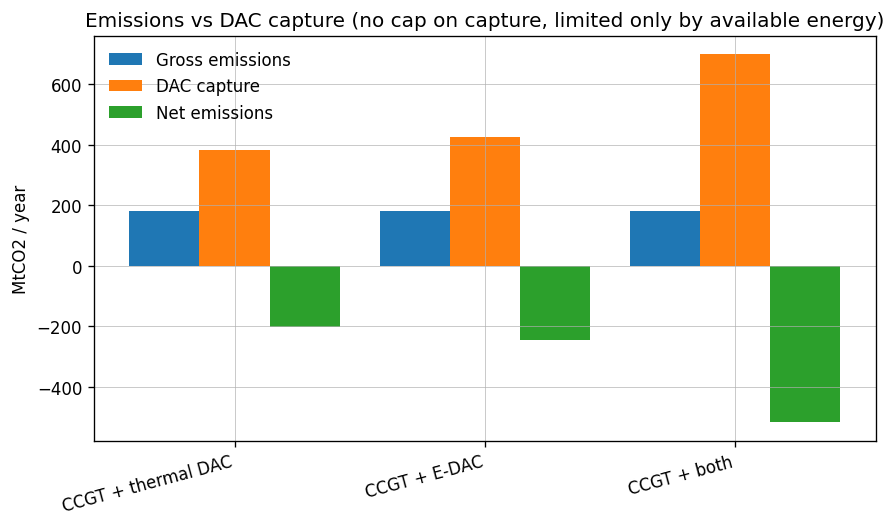

In [13]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.units import Units as U

# Parameters (Gas_techs_update)
eta = 0.55
waste_frac = 0.45
f_lowT = 1

H_heat = 1.1389 * U.MWh / U.t
elec_per_t_tdac = 0.365 * U.MWh / U.t
elec_per_t_edac = 1.25 * U.MWh / U.t
gross_intensity = 0.34 * U.t / U.MWh

gen_twh = 588 * U.TWh  # annual generation

def compute_case(gen, use_thermal: bool, use_edac: bool):
    elec_MWh = gen.to(U.MWh)
    fuel = elec_MWh / eta
    waste = fuel * waste_frac
    gross = (elec_MWh * gross_intensity).to(U.t)

    # Thermal DAC (no cap)
    usable_heat = waste * (f_lowT if use_thermal else 0)
    cap_tdac = (usable_heat / H_heat).to(U.t)
    dac_aux_tdac = (cap_tdac * elec_per_t_tdac).to(U.MWh)

    # E-DAC from remaining electricity (no cap to emissions)
    elec_left = elec_MWh - dac_aux_tdac
    cap_edac = (elec_left / elec_per_t_edac).to(U.t) if use_edac else 0 * U.t

    total_cap = cap_tdac + cap_edac
    net = (gross - total_cap).to(U.t)  # can go negative

    return {
        "Gas_emissions_MtCO2": gross.to(U.Mt).magnitude,
        "DAC_capture_MtCO2": total_cap.to(U.Mt).magnitude,
        "Net_emissions_MtCO2": net.to(U.Mt).magnitude,
    }

rows = {
    "CCGT + thermal DAC": compute_case(gen_twh, use_thermal=True, use_edac=False),
    "CCGT + E-DAC": compute_case(gen_twh, use_thermal=False, use_edac=True),
    "CCGT + both": compute_case(gen_twh, use_thermal=True, use_edac=True),
}
ccgt_emissions_results = pd.DataFrame(rows).T

# Plot
fig, ax = plt.subplots()
x = np.arange(len(ccgt_emissions_results))
width = 0.28

ax.bar(x - width, ccgt_emissions_results["Gas_emissions_MtCO2"], width, label="Gross emissions")
ax.bar(x, ccgt_emissions_results["DAC_capture_MtCO2"], width, label="DAC capture")
ax.bar(x + width, ccgt_emissions_results["Net_emissions_MtCO2"], width, label="Net emissions")

ax.set_xticks(x)
ax.set_xticklabels(ccgt_emissions_results.index, rotation=15, ha="right")
ax.set_ylabel("MtCO2 / year")
ax.set_title("Emissions vs DAC capture (no cap on capture, limited only by available energy)")
ax.legend()
plt.tight_layout()
plt.show()


C:\Users\Yutong Ren\AppData\Local\Temp\ipykernel_27912\1318602362.py:67: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


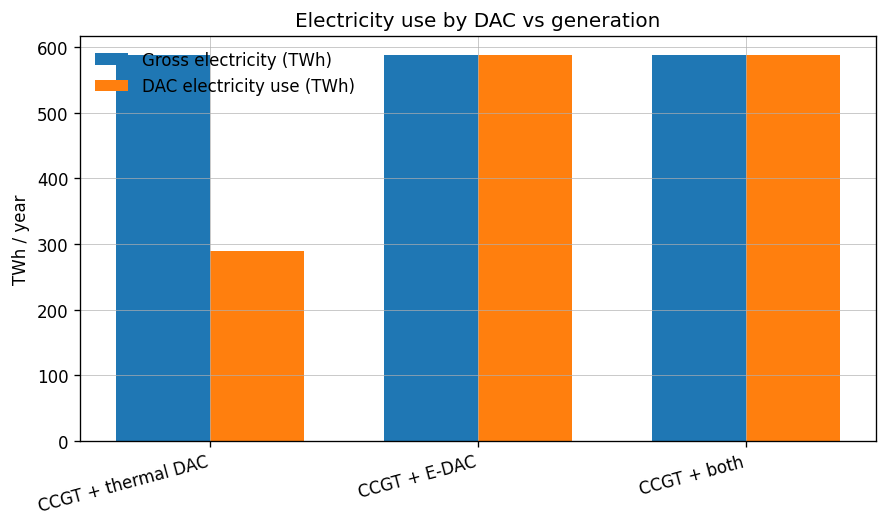

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.units import Units as U

# Parameters
eta = 0.55
waste_frac = 0.45
f_lowT = 0.50

H_heat = 0.366 * U.MWh / U.t
elec_per_t_tdac = 0.44 * U.MWh / U.t
elec_per_t_edac = 1.25 * U.MWh / U.t
gross_intensity = 0.34 * U.t / U.MWh

gen_twh = 588 * U.TWh  # annual generation

def compute_case(gen, use_thermal: bool, use_edac: bool):
    elec_MWh = gen.to(U.MWh)
    fuel = elec_MWh / eta
    waste = fuel * waste_frac
    gross = (elec_MWh * gross_intensity).to(U.t)

    # Thermal DAC (no cap)
    usable_heat = waste * (f_lowT if use_thermal else 0)
    cap_tdac = (usable_heat / H_heat).to(U.t)
    dac_aux_tdac = (cap_tdac * elec_per_t_tdac).to(U.MWh)

    # E-DAC from remaining electricity (no emissions cap; don’t let electricity go negative)
    elec_left = elec_MWh - dac_aux_tdac
    if elec_left.magnitude < 0:
        elec_left = 0 * U.MWh
    cap_edac = (elec_left / elec_per_t_edac).to(U.t) if use_edac else 0 * U.t
    dac_aux_edac = (cap_edac * elec_per_t_edac).to(U.MWh)

    total_cap = cap_tdac + cap_edac
    net = (gross - total_cap).to(U.t)  # can go negative

    return {
        "Generation_TWh": gen.to(U.TWh).magnitude,
        "DAC_electricity_TWh": (dac_aux_tdac + dac_aux_edac).to(U.TWh).magnitude,
        "Gas_emissions_MtCO2": gross.to(U.Mt).magnitude,
        "DAC_capture_MtCO2": total_cap.to(U.Mt).magnitude,
        "Net_emissions_MtCO2": net.to(U.Mt).magnitude,
    }

rows = {
    "CCGT + thermal DAC": compute_case(gen_twh, use_thermal=True, use_edac=False),
    "CCGT + E-DAC": compute_case(gen_twh, use_thermal=False, use_edac=True),
    "CCGT + both": compute_case(gen_twh, use_thermal=True, use_edac=True),
}
ccgt_energy_results = pd.DataFrame(rows).T

# Plot: electricity use by DAC vs gross generation
fig, ax = plt.subplots()
x = np.arange(len(ccgt_energy_results))
width = 0.35

ax.bar(x - width / 2, ccgt_energy_results["Generation_TWh"], width, label="Gross electricity (TWh)")
ax.bar(x + width / 2, ccgt_energy_results["DAC_electricity_TWh"], width, label="DAC electricity use (TWh)")

ax.set_xticks(x)
ax.set_xticklabels(ccgt_energy_results.index, rotation=15, ha="right")
ax.set_ylabel("TWh / year")
ax.set_title("Electricity use by DAC vs generation")
ax.legend()
plt.tight_layout()
plt.show()


In [15]:
from src.units import Units as U
import src.assumptions as A

print("GT tech_params:")
print(tech_params.loc["Gas Turbine (simple cycle)"])

print("\nH_DAC_MWH_PER_T:", H_DAC_MWH_PER_T)

print("\nA.LTDAC.ElectricityPerTonCO2:", A.LTDAC.ElectricityPerTonCO2)

# Also show the numeric balance f_lowT for GT with current values
gt = tech_params.loc["Gas Turbine (simple cycle)"]
eta = gt["eta_elec"] * U.dimensionless
waste_frac = gt["waste_frac"] * U.dimensionless
dac_elec = gt["dac_elec_per_t"]
f_low_balance = (eta / (waste_frac * (dac_elec / H_DAC_MWH_PER_T))).to(U.dimensionless)

print("\nComputed f_lowT_balance (GT):", f_low_balance)


GT tech_params:
eta_elec                                             0.33
waste_frac                                           0.68
f_lowT                                                  1
waste_temp_C                                          538
dac_elec_per_t    0.30038882547828005 megawatt_hour / ton
co2_intensity                     0.5 ton / megawatt_hour
Name: Gas Turbine (simple cycle), dtype: object

H_DAC_MWH_PER_T: 1.1389 megawatt_hour / ton

A.LTDAC.ElectricityPerTonCO2: 0.331122 megawatt_hour / metric_ton

Computed f_lowT_balance (GT): 1.8254981968325885 dimensionless
